In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from bk_tools import BASE_DIR
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Import all necessary libraries for data manipulation, visualization and deep learning.

In [2]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:

BASE_DIR = Path.cwd()
path_db = BASE_DIR / "BreaKHis_v1" / "histology_slides" / "breast"


def packup_details(f):
    p = Path(f)

    # only filename, cross-platform safe
    filename = p.name                          # SOB_B_A-14-22549G-100-001.png
    stem = p.stem                             # SOB_B_A-14-22549G-100-001

    parts = stem.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected filename format: {filename}")

    example = parts[0]                        # SOB
    is_malign = 1 if parts[1] == "M" else 0   # M -> malignant, B -> benign

    names = parts[2].split("-")
    if len(names) < 5:
        raise ValueError(f"Unexpected tumor name format: {filename}")

    class_tumor = names[0]
    year = int(names[1]) + 2000
    patient_id = names[2]
    zoom = int(names[3])
    file_id = names[4]

    return {
        "patient_id": patient_id,
        "file_id": file_id,
        "example": example,
        "class": class_tumor,
        "year": year,
        "zoom": zoom,
        "file_path": str(p),
        "is_malign": is_malign,
    }


def print_file_details(f):
    p = Path(f)
    filename = p.name
    stem = p.stem

    parts = stem.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected filename format: {filename}")

    print("Type of example:", parts[0])
    print("State:", parts[1], "(", 1 if parts[1] == "M" else 0, ")")

    nm = parts[2].split("-")
    if len(nm) < 5:
        raise ValueError(f"Unexpected tumor name format: {filename}")

    print("Class:", nm[0])
    print("Year:", nm[1])
    print("Patient ID:", nm[2])
    print("Zoom:", nm[3])
    print("File ID:", nm[4])


def prepare_data_table(rootpath=path_db) -> pd.DataFrame:
    rootpath = Path(rootpath)

    # cross-platform recursive PNG search
    files = list(rootpath.rglob("*.png"))

    if not files:
        raise FileNotFoundError(f"No PNG files found under: {rootpath}")

    datas = []
    bad_files = []

    for f in files:
        try:
            datas.append(packup_details(f))
        except Exception as e:
            bad_files.append((str(f), str(e)))

    df = pd.DataFrame(datas)

    print("DataFrame shape:", df.shape)
    print("DataFrame columns:", df.columns.tolist())
    print("Parsed files:", len(datas))
    print("Failed files:", len(bad_files))

    if bad_files:
        print("\nFirst 10 problematic files:")
        for fp, err in bad_files[:10]:
            print(fp, "->", err)

    return df

In [4]:
# Prepare the data table using the custom function from bk_tools and display its information.
df = prepare_data_table()
df.info()
df["class"].unique()

DataFrame shape: (7909, 8)
DataFrame columns: ['patient_id', 'file_id', 'example', 'class', 'year', 'zoom', 'file_path', 'is_malign']
Parsed files: 7909
Failed files: 0
<class 'pandas.DataFrame'>
RangeIndex: 7909 entries, 0 to 7908
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  7909 non-null   str  
 1   file_id     7909 non-null   str  
 2   example     7909 non-null   str  
 3   class       7909 non-null   str  
 4   year        7909 non-null   int64
 5   zoom        7909 non-null   int64
 6   file_path   7909 non-null   str  
 7   is_malign   7909 non-null   int64
dtypes: int64(3), str(5)
memory usage: 494.4 KB


<StringArray>
['MC', 'PC', 'DC', 'LC', 'A', 'TA', 'F', 'PT']
Length: 8, dtype: str

In [5]:
# Patient-wise split with class coverage in all splits (train/val/test).
chosen_zoom = 40
test_val_size = 0.4
seed = 42

df_zoom = df[df["zoom"] == chosen_zoom].copy()
print(f"Selected zoom: {chosen_zoom}")
print(f"Total samples at selected zoom: {len(df_zoom)}")
print(f"Total unique patients at selected zoom: {df_zoom['patient_id'].nunique()}")

print("\nInitial image-level class distribution:")
print(df_zoom["class"].value_counts())

# Remove patients that contain multiple classes to avoid leakage/noisy labels.
patient_class_counts = df_zoom.groupby("patient_id")["class"].nunique()
problematic_patients = patient_class_counts[patient_class_counts > 1].index.tolist()
if len(problematic_patients) > 0:
    print(f"\nRemoving {len(problematic_patients)} patient(s) with multiple classes.")
    print("Problematic patient IDs:", problematic_patients)
    df_zoom = df_zoom[~df_zoom["patient_id"].isin(problematic_patients)].copy()

patient_level = df_zoom[["patient_id", "class"]].drop_duplicates().reset_index(drop=True)
print("\nClean patient-level class distribution:")
print(patient_level["class"].value_counts())

rng = np.random.default_rng(seed)
train_patients, val_patients, test_patients = [], [], []

for cls_name, grp in patient_level.groupby("class"):
    patients = grp["patient_id"].to_numpy().copy()
    rng.shuffle(patients)
    n = len(patients)

    if n < 3:
        raise ValueError(
            f"Class {cls_name} has only {n} patient(s). Need at least 3 for train/val/test coverage."
        )

    # Allocate at least 1 patient to each split for every class.
    n_temp = int(round(n * test_val_size))
    n_temp = max(2, min(n - 1, n_temp))
    n_train = n - n_temp

    n_val = n_temp // 2
    n_test = n_temp - n_val
    if n_val == 0:
        n_val, n_test = 1, n_temp - 1
    if n_test == 0:
        n_test, n_val = 1, n_temp - 1

    train_patients.extend(patients[:n_train].tolist())
    val_patients.extend(patients[n_train:n_train + n_val].tolist())
    test_patients.extend(patients[n_train + n_val:n_train + n_val + n_test].tolist())

train_df = df_zoom[df_zoom["patient_id"].isin(train_patients)].reset_index(drop=True)
val_df = df_zoom[df_zoom["patient_id"].isin(val_patients)].reset_index(drop=True)
test_df = df_zoom[df_zoom["patient_id"].isin(test_patients)].reset_index(drop=True)

# Safety checks: no patient overlap.
assert set(train_df["patient_id"]) & set(val_df["patient_id"]) == set()
assert set(train_df["patient_id"]) & set(test_df["patient_id"]) == set()
assert set(val_df["patient_id"]) & set(test_df["patient_id"]) == set()

print("\nPatient split check:")
print("Train patients:", train_df["patient_id"].nunique())
print("Val patients  :", val_df["patient_id"].nunique())
print("Test patients :", test_df["patient_id"].nunique())

print("\nFinal image-level class distribution:")
print("\nTrain:")
print(train_df["class"].value_counts())
print("\nValidation:")
print(val_df["class"].value_counts())
print("\nTest:")
print(test_df["class"].value_counts())

print("\nFinal sample counts:")
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

print("\nValidation class counts:")
print(val_df["class"].value_counts())

Selected zoom: 40
Total samples at selected zoom: 1995
Total unique patients at selected zoom: 81

Initial image-level class distribution:
class
DC    864
F     253
MC    205
LC    156
TA    149
PC    145
A     114
PT    109
Name: count, dtype: int64

Removing 1 patient(s) with multiple classes.
Problematic patient IDs: ['13412']

Clean patient-level class distribution:
class
DC    37
F     10
MC     9
TA     7
PC     6
LC     4
A      4
PT     3
Name: count, dtype: int64

Patient split check:
Train patients: 46
Val patients  : 16
Test patients : 18

Final image-level class distribution:

Train:
class
DC    506
F     173
MC    102
TA    101
PC     98
LC     73
A      50
PT     38
Name: count, dtype: int64

Validation:
class
DC    134
PT     58
F      48
A      35
MC     31
LC     31
PC     30
TA     16
Name: count, dtype: int64

Test:
class
DC    192
MC     72
TA     32
F      32
A      29
LC     20
PC     17
PT     13
Name: count, dtype: int64

Final sample counts:
Train: 1141
Validat

In [6]:
CLASS_NAMES = ['MC', 'PC', 'DC', 'LC', 'A', 'TA', 'F', 'PT']
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(CLASS_NAMES)}
idx_to_class = {idx: cls_name for cls_name, idx in class_to_idx.items()}

train_df["label"] = train_df["class"].map(class_to_idx)
val_df["label"] = val_df["class"].map(class_to_idx)
test_df["label"] = test_df["class"].map(class_to_idx)

In [7]:
from tensorflow.keras.applications.convnext import preprocess_input
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 8
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)  
    return image, label

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),

    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
])

2026-04-02 23:03:54.333103: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-02 23:03:54.333131: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-02 23:03:54.333134: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-02 23:03:54.333147: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-02 23:03:54.333156: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
def make_dataset(df, training=False):
    image_paths = df["file_path"].values
    labels = df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()

    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [9]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

In [10]:
from tensorflow.keras import layers, models
from tensorflow.keras import applications

def build_pretrained_sequential_model(input_shape=(224, 224, 3), num_classes=8):

    base_model = tf.keras.applications.DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        classes=8,
        classifier_activation='softmax'
    )


    model = models.Sequential([
        tf.keras.Input(shape=input_shape),
        layers.Lambda(lambda x: tf.keras.applications.densenet.preprocess_input(x)),        
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.LayerNormalization(epsilon=1e-5),
        layers.Dropout(0.5),
        layers.Dense(
            num_classes, 
            activation="softmax", 
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        )
    ])

    return model, base_model

In [11]:
from bk_tools import BASE_DIR


model, base_model = build_pretrained_sequential_model(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")
    ]
)

MODEL_DIR = BASE_DIR/"models"
MODEL_DIR.mkdir(exist_ok=True)


callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10, # Cosine dalgası bazen geç toparlar, sabrı artırdık
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "models/best_model_densenet.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
    # ReduceLROnPlateau'ya ARTIK GEREK YOK çünkü CosineDecay bu işi baştan planlıyor.
]
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 1024)           │         2,048 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         8,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,047,752 (26.89 MB)

 Trainable params: 6,964,104 (26.57 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [12]:
# Class weights from provided train class counts.
class_counts = {
    "DC": 449,
    "F": 158,
    "MC": 89,
    "PC": 88,
    "TA": 83,
    "LC": 58,
    "A": 47,
    "PT": 39,
}

total_samples = sum(class_counts.values())
num_classes = len(class_counts)

raw_class_weight_by_name = {
    cls_name: total_samples / (num_classes * count)
    for cls_name, count in class_counts.items()
}

min_w = min(raw_class_weight_by_name.values())
class_weight_by_name = {
    cls_name: weight / min_w
    for cls_name, weight in raw_class_weight_by_name.items()
}

class_weight_map = {
    class_to_idx[cls_name]: weight
    for cls_name, weight in class_weight_by_name.items()
}

raw = {c: total_samples / (num_classes * n) for c, n in class_counts.items()}
soft = {c: (w ** 0.5) for c, w in raw.items()}   # soften
m = min(soft.values())
soft = {c: min(max(w / m, 1.0), 4.0) for c, w in soft.items()}  # min=1, max=4
class_weight_map = {class_to_idx[c]: w for c, w in soft.items()}

print("Raw class weight by class name:")
for cls_name in CLASS_NAMES:
    print(f"{cls_name}: {raw_class_weight_by_name[cls_name]:.4f}")

print("\nRescaled class weight by class name (min=1.0):")
for cls_name in CLASS_NAMES:
    print(f"{cls_name}: {class_weight_by_name[cls_name]:.4f}")

print("\nClass weight map (label -> weight):")
print(class_weight_map)


class_weight_map[class_to_idx["DC"]] *= 0.7

def get_advanced_metrics():
    return [
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
        tf.keras.metrics.SparseCategoricalCrossentropy(name="cross_entropy"),
    ]

Raw class weight by class name:
MC: 1.4199
PC: 1.4361
DC: 0.2815
LC: 2.1789
A: 2.6888
TA: 1.5226
F: 0.7998
PT: 3.2404

Rescaled class weight by class name (min=1.0):
MC: 5.0449
PC: 5.1023
DC: 1.0000
LC: 7.7414
A: 9.5532
TA: 5.4096
F: 2.8418
PT: 11.5128

Class weight map (label -> weight):
{2: 1.0, 6: 1.6857556619803282, 0: 2.246095238458227, 1: 2.2588210923560825, 5: 2.32586296978495, 3: 2.782333429038444, 4: 3.090823755790954, 7: 3.3930547465109537}


In [13]:
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # stage2 için 5e-6
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")
    ]
)
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_map,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


2026-04-02 23:03:56.425293: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.2171 - loss: 4.7478 - top2_acc: 0.3582
Epoch 1: val_loss improved from None to 1.91840, saving model to models/best_model_densenet.keras

Epoch 1: finished saving model to models/best_model_densenet.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 500ms/step - accuracy: 0.2340 - loss: 4.3514 - top2_acc: 0.4040 - val_accuracy: 0.4282 - val_loss: 1.9184 - val_top2_acc: 0.5535 - learning_rate: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.3019 - loss: 3.3538 - top2_acc: 0.5259
Epoch 2: val_loss improved from 1.91840 to 1.66329, saving model to models/best_model_densenet.keras

Epoch 2: finished saving model to models/best_model_densenet.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 354ms/step - accuracy: 0.3094 - loss: 3.4063 - top2_acc: 0.5197 - val_accuracy: 0.4543 - val_loss: 1.6633 - val_top2_acc: 0.5927 - learning_rate: 0.0010
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.4036 - loss: 2.7196 - top2_acc: 

In [14]:
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=4e-5),  # stage2 için 5e-6
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")
    ]
)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=20,
    epochs=50,
    class_weight=class_weight_map,
    callbacks=callbacks,
    verbose=1
)

Epoch 21/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.5611 - loss: 1.8870 - top2_acc: 0.7848
Epoch 21: val_loss did not improve from 1.62182
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 483ms/step - accuracy: 0.5565 - loss: 1.9401 - top2_acc: 0.7783 - val_accuracy: 0.5091 - val_loss: 1.6245 - val_top2_acc: 0.6475 - learning_rate: 4.0000e-05
Epoch 22/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.5443 - loss: 1.9461 - top2_acc: 0.7559
Epoch 22: val_loss did not improve from 1.62182
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 347ms/step - accuracy: 0.5469 - loss: 1.9656 - top2_acc: 0.7730 - val_accuracy: 0.5039 - val_loss: 1.6595 - val_top2_acc: 0.6501 - learning_rate: 4.0000e-05
Epoch 23/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.5601 - loss: 1.8129 - top2_acc: 0.7810
Epoch 23: val_loss did not improve from 1.62182
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step - accuracy: 0.5521 - loss: 1.8740 - top2_acc: 0.7686 - val_accuracy: 0.4961 - val_loss: 1.6540 - val_top2_acc: 0.6501 - 

In [15]:
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")
    ]
)

history_stage3 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=50,
    epochs=70,
    class_weight=class_weight_map,
    callbacks=callbacks,
    verbose=1
)

Epoch 51/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.6049 - loss: 1.7721 - top2_acc: 0.8268
Epoch 51: val_loss did not improve from 1.62182
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 488ms/step - accuracy: 0.5828 - loss: 1.9066 - top2_acc: 0.7993 - val_accuracy: 0.5065 - val_loss: 1.6268 - val_top2_acc: 0.6449 - learning_rate: 2.0000e-06
Epoch 52/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.5773 - loss: 1.8080 - top2_acc: 0.8069
Epoch 52: val_loss did not improve from 1.62182
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 349ms/step - accuracy: 0.5592 - loss: 1.8972 - top2_acc: 0.7879 - val_accuracy: 0.5065 - val_loss: 1.6285 - val_top2_acc: 0.6449 - learning_rate: 2.0000e-06
Epoch 53/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.5858 - loss: 1.8159 - top2_acc: 0.7927
Epoch 53: val_loss did not improve from 1.62182
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 349ms/step - accuracy: 0.5741 - loss: 1.8887 - top2_acc: 0.7914 - val_accuracy: 0.5091 - val_loss: 1.6303 - val_top2_acc: 0.6475 - 

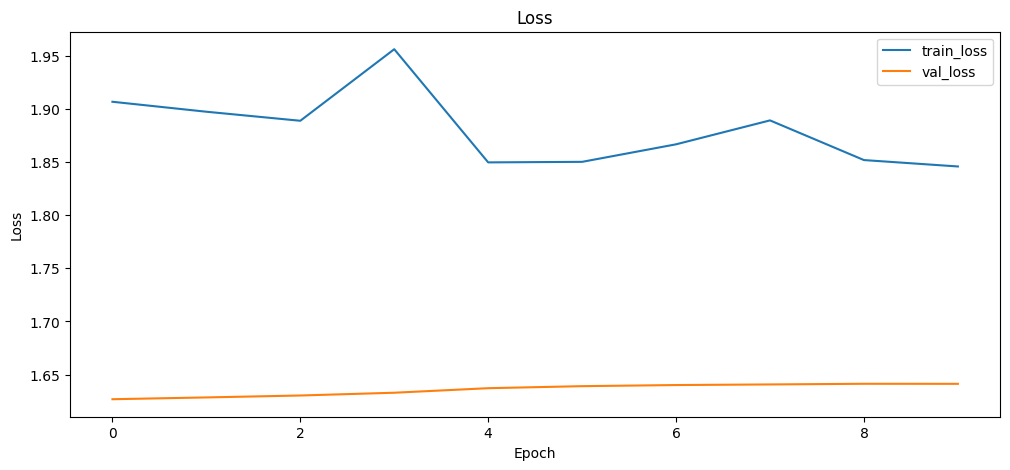

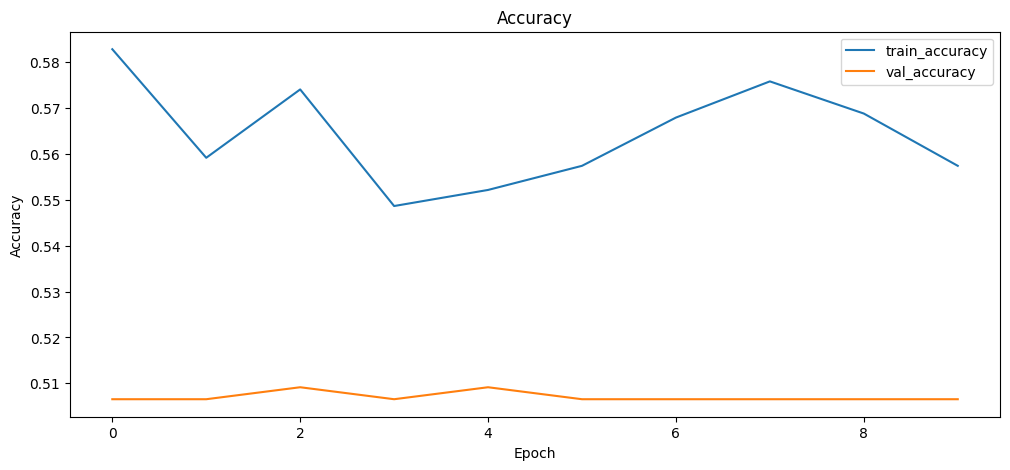

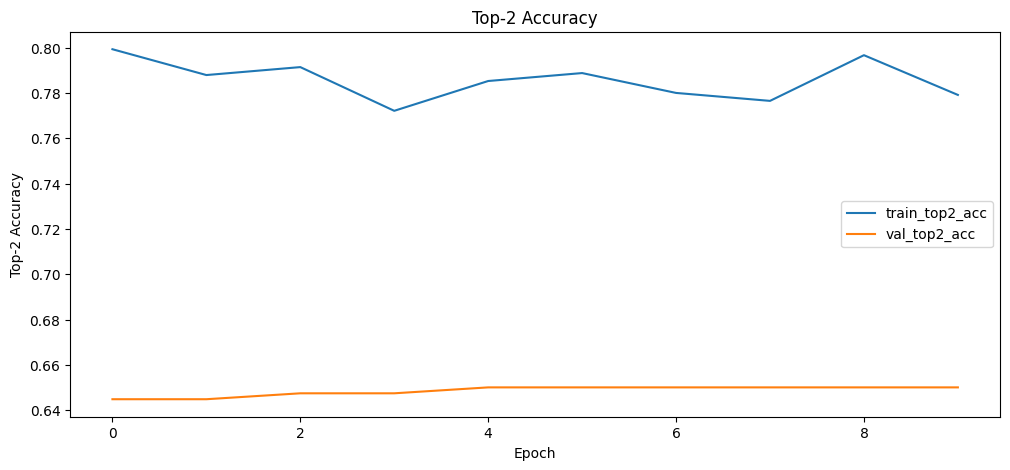

In [16]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    history_dict = history.history

    plt.figure(figsize=(12, 5))
    plt.plot(history_dict["loss"], label="train_loss")
    plt.plot(history_dict["val_loss"], label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(history_dict["accuracy"], label="train_accuracy")
    plt.plot(history_dict["val_accuracy"], label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    if "top2_acc" in history_dict and "val_top2_acc" in history_dict:
        plt.figure(figsize=(12, 5))
        plt.plot(history_dict["top2_acc"], label="train_top2_acc")
        plt.plot(history_dict["val_top2_acc"], label="val_top2_acc")
        plt.title("Top-2 Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Top-2 Accuracy")
        plt.legend()
        plt.show()

plot_training_history(history_stage3)

In [17]:
test_loss ,test_acc, cross_ent = model.evaluate(test_ds, verbose=1)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")



y_true = test_df["label"].values
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.5061 - loss: 1.5468 - top2_acc: 0.6314
Test Loss     : 1.5468
Test Accuracy : 0.5061
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 497ms/step


In [18]:
from sklearn.metrics import classification_report

CLASS_NAMES = ['MC', 'PC', 'DC', 'LC', 'A', 'TA', 'F', 'PT']

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

          MC     0.0000    0.0000    0.0000        72
          PC     0.1231    0.4706    0.1951        17
          DC     0.7111    0.8333    0.7674       192
          LC     0.0000    0.0000    0.0000        20
           A     0.2857    0.4828    0.3590        29
          TA     0.5455    0.1875    0.2791        32
           F     0.4118    0.4375    0.4242        32
          PT     0.5714    0.3077    0.4000        13

    accuracy                         0.5061       407
   macro avg     0.3311    0.3399    0.3031       407
weighted avg     0.4545    0.5061    0.4638       407



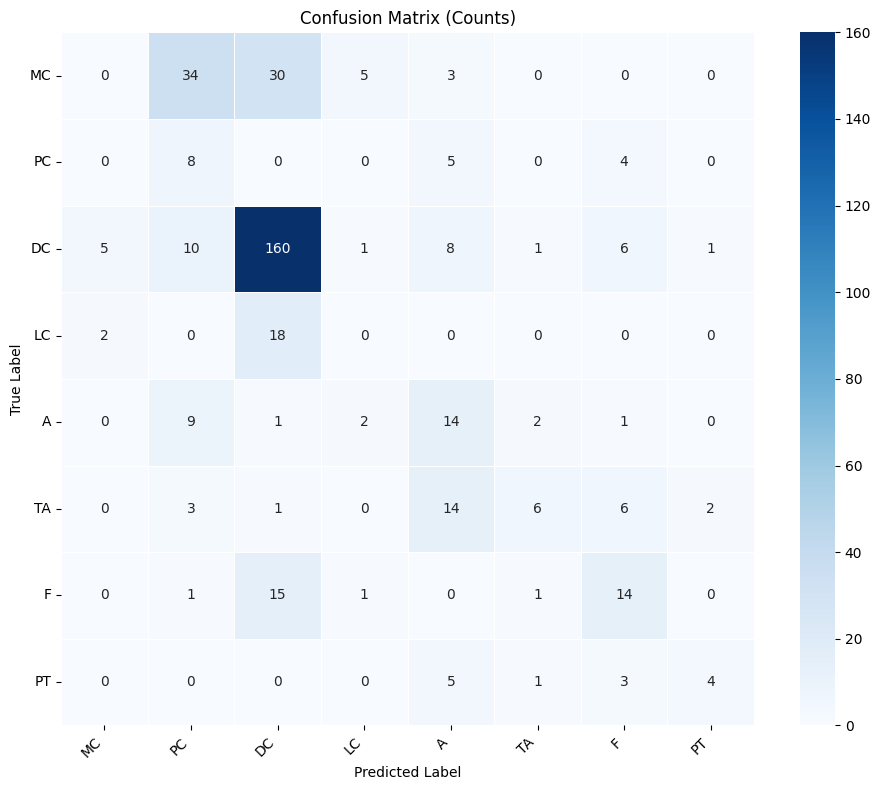

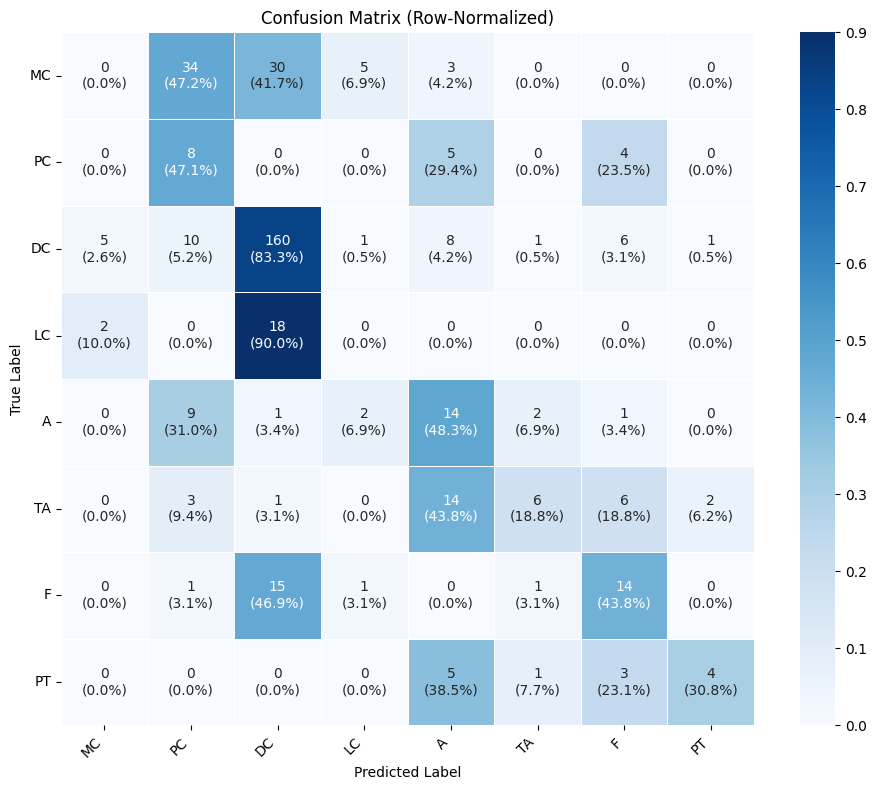

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False, cmap="Blues"):
    cm = np.asarray(cm)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1, row_sums)
        cm_to_plot = cm.astype(np.float64) / row_sums

        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f"{cm[i, j]}\n({cm_to_plot[i, j] * 100:.1f}%)"
        fmt = ""
    else:
        cm_to_plot = cm
        annot = cm
        fmt = "d"

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_to_plot,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        linewidths=0.5,
        linecolor="white",
        square=True
    )
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, CLASS_NAMES, title="Confusion Matrix (Counts)", normalize=False)
plot_confusion_matrix(cm, CLASS_NAMES, title="Confusion Matrix (Row-Normalized)", normalize=True)